# 03 — Feature Engineering

This notebook creates the derived features, performs cleaned statistical analysis, demonstrates Truncated SVD dimensionality reduction and F-test feature selection, and saves the engineered dataset for modelling.

### Imports — why this cell is needed
Loads the libraries required for feature construction, statistics, SVD, and feature selection.

In [1]:
import re
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectPercentile, f_regression
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score
)

### Repository paths — why this cell is needed
Loads the processed dataset and saves figures using repository-relative paths.

In [2]:
def find_repo_root():
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError(
        "Repository root not found. Run this notebook from inside the cloned "
        "CSE437 repository, with data/ and notebooks/ folders present."
    )

ROOT = find_repo_root()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
FIGURES_DIR = ROOT / "figures"
MODELS_DIR = ROOT / "models"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root:", ROOT)

Repository root: /content/cse437-building-energy-G9


### Load the cleaned dataset — why this cell is needed
Uses the output produced by `02_preprocessing.ipynb`.

In [3]:
CLEANED_CSV = PROCESSED_DIR / "seattle_energy_cleaned.csv"
if not CLEANED_CSV.exists():
    raise FileNotFoundError(
        "Run 02_preprocessing.ipynb first. "
        "Expected data/processed/seattle_energy_cleaned.csv"
    )

df = pd.read_csv(CLEANED_CSV, low_memory=False)
print("Loaded:", CLEANED_CSV.relative_to(ROOT))
print("Shape:", df.shape)
display(df.head())

Loaded: data/processed/seattle_energy_cleaned.csv
Shape: (34822, 22)


,OSEBuildingID,SiteEUI,DataYear,BuildingType,EPAPropertyType,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,Neighborhood,CouncilDistrictCode,...,NumberofFloors,NumberofBuildings,PropertyGFATotal,PropertyGFABuilding,PropertyGFAParking,LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,Latitude,Longitude
0,2,69.3,2025,NonResidential,Hotel,Hotel,Parking,NaN,EAST,7,...,11.0,1.0,103566.0,88502.0,15064.0,88502.0,15064.0,NaN,47.613073,-122.333607
1,3,89.9,2025,NonResidential,Hotel,Hotel,Parking,Swimming Pool,LAKE UNION,7,...,41.0,3.0,956110.0,759392.0,196718.0,827566.0,117783.0,NaN,47.613672,-122.338221
2,5,83.6,2025,NonResidential,Hotel,Hotel,NaN,NaN,LAKE UNION,7,...,10.0,1.0,61320.0,61320.0,0.0,61320.0,NaN,NaN,47.614121,-122.336637
3,8,86.1,2025,NonResidential,Hotel,Hotel,Parking,Swimming Pool,LAKE UNION,7,...,18.0,1.0,175580.0,113580.0,62000.0,123445.0,68009.0,NaN,47.613950,-122.340871
4,9,172.1,2025,NonResidential,Police Station,Police Station,Parking,NaN,LAKE UNION,7,...,2.0,1.0,97288.0,60090.0,37198.0,50755.0,40971.0,NaN,47.616235,-122.336567


### Create derived features — why this cell is needed
Builds the seven non-leakage features used in the final project.

In [4]:
if {"DataYear", "YearBuilt"}.issubset(df.columns):
    df["BuildingAge"] = df["DataYear"] - df["YearBuilt"]

if {"PropertyGFATotal", "NumberofFloors"}.issubset(df.columns):
    df["GFA_per_Floor"] = (
        df["PropertyGFATotal"]
        / df["NumberofFloors"]
    )

if {"PropertyGFAParking", "PropertyGFATotal"}.issubset(df.columns):
    df["ParkingRatio"] = (
        df["PropertyGFAParking"]
        / df["PropertyGFATotal"]
    )

for gfa_col, output_col in [
    ("LargestPropertyUseTypeGFA", "LargestUseRatio"),
    ("SecondLargestPropertyUseTypeGFA", "SecondUseRatio"),
    ("ThirdLargestPropertyUseTypeGFA", "ThirdUseRatio")
]:
    if {gfa_col, "PropertyGFATotal"}.issubset(df.columns):
        df[output_col] = (
            df[gfa_col]
            / df["PropertyGFATotal"]
        )

if "PropertyGFATotal" in df.columns:
    df["LogPropertyGFATotal"] = np.log1p(
        df["PropertyGFATotal"].clip(lower=0)
    )

engineered_features = [
    c for c in [
        "BuildingAge",
        "GFA_per_Floor",
        "ParkingRatio",
        "LargestUseRatio",
        "SecondUseRatio",
        "ThirdUseRatio",
        "LogPropertyGFATotal"
    ] if c in df.columns
]

print("Engineered features:", engineered_features)

Engineered features: ['BuildingAge', 'GFA_per_Floor', 'ParkingRatio', 'LargestUseRatio', 'SecondUseRatio', 'ThirdUseRatio', 'LogPropertyGFATotal']


### Save the engineered dataset — why this cell is needed
Creates the input used by modelling and evaluation notebooks.

In [5]:
ENGINEERED_CSV = PROCESSED_DIR / "seattle_energy_features.csv"
df.to_csv(ENGINEERED_CSV, index=False)
print("Saved:", ENGINEERED_CSV.relative_to(ROOT))
print("Shape:", df.shape)

Saved: data/processed/seattle_energy_features.csv
Shape: (34822, 29)


## Statistical analysis

### Property-type relationship — why this cell is needed
Shows how median SiteEUI differs across major EPA property types and saves the report figure.

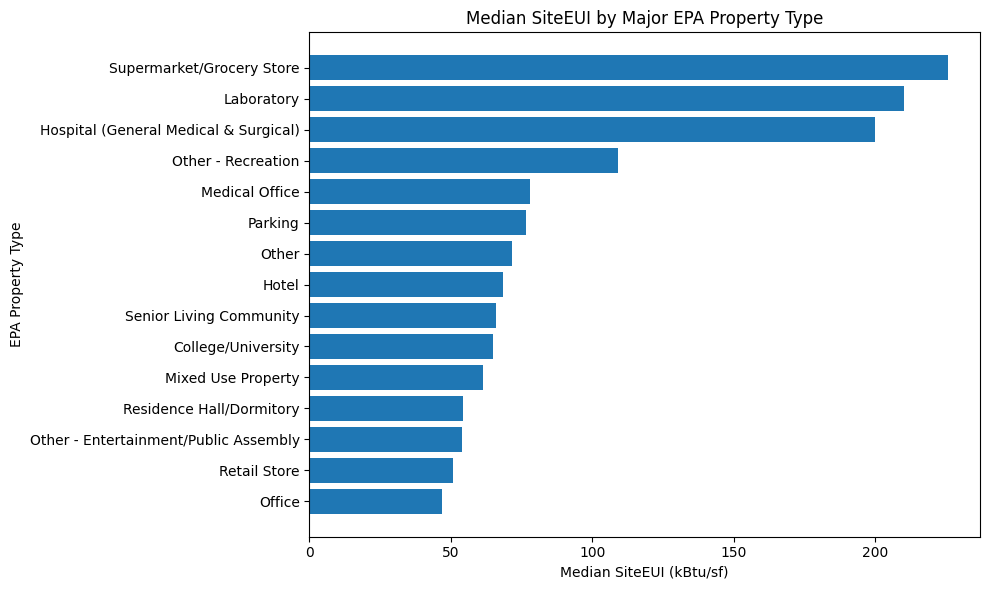

In [6]:
property_plot = (
    df.groupby("EPAPropertyType")["SiteEUI"]
    .agg(["count", "median"])
)

property_plot = property_plot[property_plot["count"] >= 100]


property_plot = (
    property_plot
    .sort_values("median", ascending=False)
    .head(15)
    .sort_values("median")
)

plt.figure(figsize=(10, 6))
plt.barh(property_plot.index.astype(str), property_plot["median"])
plt.xlabel("Median SiteEUI (kBtu/sf)")
plt.ylabel("EPA Property Type")
plt.title("Median SiteEUI by Major EPA Property Type")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "median_siteeui_by_epa_property_type.png", dpi=200, bbox_inches="tight")
plt.show()

### Descriptive statistics — why this cell is needed
Summarizes the cleaned target, numerical predictors, and property-type groups.

In [7]:
print("Target descriptive statistics:")
display(df["SiteEUI"].describe().to_frame().T)

numeric_stat_cols = [
    c for c in df.select_dtypes(include=np.number).columns
    if c != "SiteEUI"
]

print("\nNumerical predictor statistics:")
display(df[numeric_stat_cols].describe().T)

group_col = (
    "EPAPropertyType"
    if "EPAPropertyType" in df.columns
    else "BuildingType"
)

if group_col in df.columns:
    print(f"\nSiteEUI by {group_col}:")
    display(
        df.groupby(group_col, dropna=False)["SiteEUI"]
        .agg(["count", "mean", "median", "std"])
        .sort_values("count", ascending=False)
        .head(20)
    )

Target descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
SiteEUI,34822.0,51.027365,48.864739,0.1,27.5,36.6,56.099998,784.0



Numerical predictor statistics:


,count,mean,std,min,25%,50%,75%,max
OSEBuildingID,34822.0,23174.716788,13862.909418,1.000000,20224.000000,23462.000000,26723.000000,5.211400e+04
DataYear,34822.0,2020.130952,3.175323,2015.000000,2017.000000,2020.000000,2023.000000,2.025000e+03
CouncilDistrictCode,34822.0,4.233846,2.240634,1.000000,2.000000,4.000000,7.000000,7.000000e+00
ZipCode,34822.0,98116.507668,16.767620,98101.000000,98105.000000,98112.000000,98122.000000,9.819900e+04
YearBuilt,34821.0,1973.141639,34.144212,1900.000000,1954.000000,1980.000000,2001.000000,2.024000e+03
NumberofFloors,34739.0,5.139094,5.778164,1.000000,3.000000,4.000000,6.000000,7.600000e+01
NumberofBuildings,34581.0,1.271826,5.517213,1.000000,1.000000,1.000000,1.000000,3.000000e+02
PropertyGFATotal,34822.0,109671.750416,301419.189499,16092.000000,29874.000000,47647.000000,102500.000000,1.521647e+07
PropertyGFABuilding,34822.0,93030.462840,283098.432133,12806.000000,27748.000000,44000.000000,89549.750000,1.521647e+07
PropertyGFAParking,34814.0,16645.112311,47724.826081,0.000000,0.000000,0.000000,10642.000000,6.867500e+05



SiteEUI by EPAPropertyType:


,count,mean,median,std
EPAPropertyType,,,,
Multifamily LR (1-4),9348,34.824572,30.000000,18.468370
Multifamily MR (5-9),6291,37.765316,33.500000,16.412797
Office,4695,54.063962,46.900002,33.423678
Multifamily Housing,1856,34.971067,31.200000,14.948948
Non-Refrigerated Warehouse,1466,33.962551,26.799999,26.347033
K-12 School,1349,42.341586,38.400002,18.348553
Mixed Use Property,1341,84.622073,61.200001,72.792527
Multifamily HR (10+),1101,47.975204,45.799999,18.227665
Hotel,772,72.891321,68.400002,35.932671


## Dimensionality reduction and feature selection

### Grouped split — why this cell is needed
Creates a leakage-safe development set for fitting feature transformations.

In [8]:
TARGET = "SiteEUI"
GROUP = "OSEBuildingID"

X = df.drop(columns=[TARGET, GROUP])
y = df[TARGET]
groups = df[GROUP]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

dev_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_dev = X.iloc[dev_idx].reset_index(drop=True)
y_dev = y.iloc[dev_idx].reset_index(drop=True)
groups_dev = groups.iloc[dev_idx].reset_index(drop=True)

X_test = X.iloc[test_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)
groups_test = groups.iloc[test_idx].reset_index(drop=True)

shared_buildings = set(groups_dev).intersection(set(groups_test))

print("Development rows:", len(X_dev))
print("Test rows:", len(X_test))
print("Development buildings:", groups_dev.nunique())
print("Test buildings:", groups_test.nunique())
print("Shared building IDs:", len(shared_buildings))

assert len(shared_buildings) == 0

Development rows: 27807
Test rows: 7015
Development buildings: 3020
Test buildings: 756
Shared building IDs: 0


### Define preprocessing — why this cell is needed
Creates the same clipping, imputation, scaling, and encoding used by the final models.

In [9]:
numeric_features = X_dev.select_dtypes(include=np.number).columns.tolist()
categorical_features = [
    c for c in X_dev.columns
    if c not in numeric_features
]


for col in categorical_features:
    X_dev[col] = X_dev[col].astype(object)
    X_test[col] = X_test[col].astype(object)
    X_dev[col] = X_dev[col].where(pd.notna(X_dev[col]), np.nan)
    X_test[col] = X_test[col].where(pd.notna(X_test[col]), np.nan)

class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, lower=0.01, upper=0.99):
        self.columns = columns
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = X.copy()
        self.bounds_ = {}
        for col in self.columns or []:
            series = pd.to_numeric(X[col], errors="coerce")
            self.bounds_[col] = (
                series.quantile(self.lower),
                series.quantile(self.upper)
            )
        return self

    def transform(self, X):
        X = X.copy()
        for col, (low, high) in self.bounds_.items():
            if col in X.columns:
                X[col] = pd.to_numeric(
                    X[col], errors="coerce"
                ).clip(low, high)
        return X

def make_preprocessor():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(
            strategy="median",
            keep_empty_features=True
        )),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(
            strategy="most_frequent",
            keep_empty_features=True
        )),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=10,
            sparse_output=False
        ))
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ], remainder="drop")

print("Numeric predictors:", len(numeric_features))
print("Categorical predictors:", len(categorical_features))
print("Missing development cells before preprocessing:",
      int(X_dev.isna().sum().sum()))

Numeric predictors: 21
Categorical predictors: 6
Missing development cells before preprocessing: 103655


### Prepare the transformed development matrix — why this cell is needed
Fits preprocessing on development data only so SVD and feature selection are leakage-safe.

In [10]:
clip_demo = QuantileClipper(
    columns=numeric_features,
    lower=0.01,
    upper=0.99
).fit(X_dev)

X_clip_demo = clip_demo.transform(X_dev)

preprocessor_demo = make_preprocessor()
X_prepared_demo = preprocessor_demo.fit_transform(X_clip_demo, y_dev)

print("Transformed development matrix:", X_prepared_demo.shape)

Transformed development matrix: (27807, 253)


### Truncated SVD — why this cell is needed
Demonstrates dimensionality reduction and reports cumulative explained variance.

,Component,Explained Variance Ratio,Cumulative Explained Variance
0,1,0.264125,0.264125
1,2,0.047876,0.312001
2,3,0.071505,0.383506
3,4,0.059920,0.443426
4,5,0.067324,0.510749
5,6,0.054501,0.565251
6,7,0.048167,0.613418
7,8,0.045290,0.658707
8,9,0.040784,0.699491
9,10,0.034821,0.734312


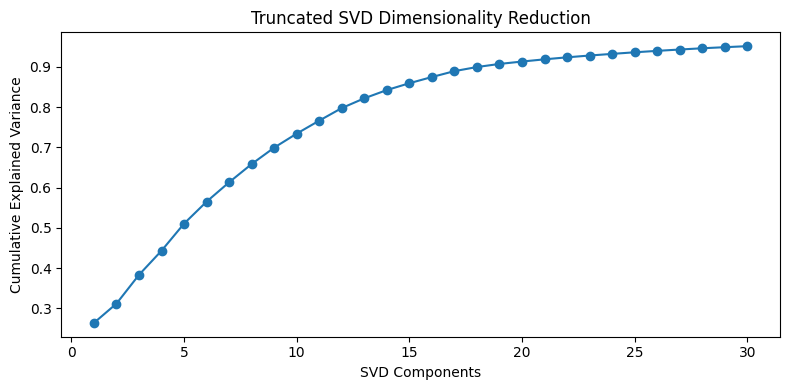

In [11]:
max_components = max(
    2,
    min(30, X_prepared_demo.shape[1] - 1)
)

svd_demo = TruncatedSVD(
    n_components=max_components,
    random_state=RANDOM_STATE
)
svd_demo.fit(X_prepared_demo)

svd_summary = pd.DataFrame({
    "Component": np.arange(1, max_components + 1),
    "Explained Variance Ratio":
        svd_demo.explained_variance_ratio_,
    "Cumulative Explained Variance":
        np.cumsum(svd_demo.explained_variance_ratio_)
})

display(svd_summary)

plt.figure(figsize=(8, 4))
plt.plot(
    svd_summary["Component"],
    svd_summary["Cumulative Explained Variance"],
    marker="o"
)
plt.xlabel("SVD Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Truncated SVD Dimensionality Reduction")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "svd_explained_variance.png", dpi=200, bbox_inches="tight")
plt.show()

### Feature selection — why this cell is needed
Uses an F-test filter to demonstrate which transformed features are retained at a 70% threshold.

In [12]:
selector_demo = SelectPercentile(
    score_func=f_regression,
    percentile=70
)
selector_demo.fit(
    X_prepared_demo,
    np.log1p(y_dev)
)

all_feature_names = (
    preprocessor_demo.get_feature_names_out()
)
selected_mask = selector_demo.get_support()
selected_names = all_feature_names[selected_mask]

print("Features after preprocessing:",
      len(all_feature_names))
print("Features retained at 70%:",
      len(selected_names))

display(
    pd.DataFrame({
        "Selected Feature": selected_names
    }).head(60)
)

Features after preprocessing: 253
Features retained at 70%: 177


,Selected Feature
0,numeric__DataYear
1,numeric__CouncilDistrictCode
2,numeric__ZipCode
3,numeric__YearBuilt
4,numeric__NumberofFloors
5,numeric__NumberofBuildings
6,numeric__PropertyGFATotal
7,numeric__PropertyGFABuilding
8,numeric__PropertyGFAParking
9,numeric__LargestPropertyUseTypeGFA
